In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

from tensorflow.keras.applications import VGG16

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [48]:
dataset_url = (
    "https://storage.googleapis.com/"
    "download.tensorflow.org/example_images/flower_photos.tgz"
)

In [49]:
dataset_path = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print("Original Dataset Path:")
print(dataset_path)

Original Dataset Path:
/root/.keras/datasets/flower_photos


In [50]:
possible_path = os.path.join(
    dataset_path,
    "flower_photos"
)

if os.path.exists(possible_path):

    dataset_path = possible_path

print("\nFinal Dataset Path:")
print(dataset_path)


Final Dataset Path:
/root/.keras/datasets/flower_photos/flower_photos


In [51]:
print("\nContents of Dataset Directory:")

for item in os.listdir(dataset_path):
    print(item)


Contents of Dataset Directory:
sunflowers
tulips
LICENSE.txt
roses
daisy
dandelion


In [52]:
class_names = [
    "daisy",
    "dandelion",
    "roses",
    "sunflowers",
    "tulips"
]

In [53]:

print("\nChecking class folders...")

for class_name in class_names:

    class_path = os.path.join(
        dataset_path,
        class_name
    )

    if os.path.exists(class_path):

        image_files = [
            file
            for file in os.listdir(class_path)
            if file.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        print(
            class_name,
            "->",
            len(image_files),
            "images"
        )

    else:

        print(
            class_name,
            "-> NOT FOUND"
        )


Checking class folders...
daisy -> 633 images
dandelion -> 898 images
roses -> 641 images
sunflowers -> 699 images
tulips -> 799 images


In [54]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [55]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [56]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [57]:
class_names = train_dataset.class_names

print("Class Names:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Class Names:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Number of Classes: 5


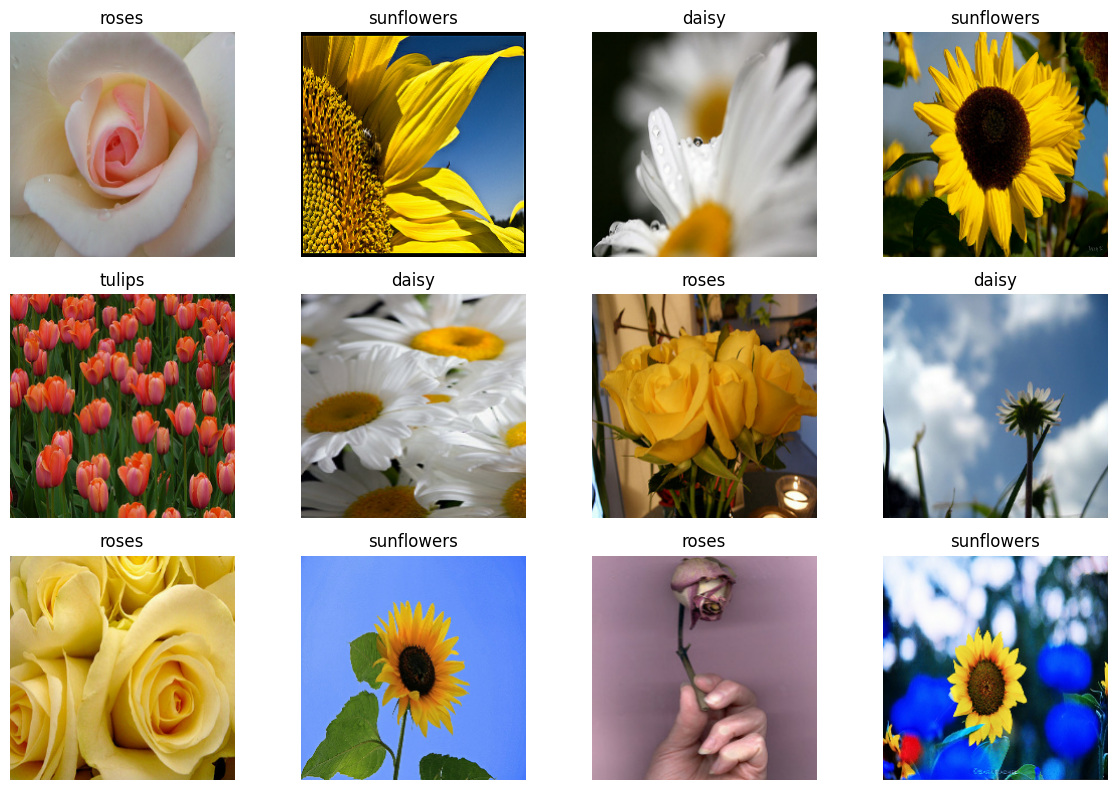

In [79]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
train_dataset = train_dataset.shuffle(
    10000
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [60]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2, strides=2),

    layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2, strides=2),

    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2, strides=2),

    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2, strides=2),

    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.Conv2D(512, kernel_size=3, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2, strides=2),

    layers.Flatten(),
    layers.Dense(4096, activation="relu"),
    layers.Dense(4096, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [63]:
histor=model.fit(train_dataset,validation_data=test_dataset,epochs=5)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.2023 - loss: 1.7238 - val_accuracy: 0.1621 - val_loss: 1.6142
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step - accuracy: 0.2255 - loss: 1.6156 - val_accuracy: 0.2480 - val_loss: 1.5960
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.2159 - loss: 1.6139 - val_accuracy: 0.2602 - val_loss: 1.5947
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 586ms/step - accuracy: 0.2224 - loss: 1.6126 - val_accuracy: 0.2602 - val_loss: 1.5927
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 57s 580ms/step - accuracy: 0.2268 - loss: 1.6082 - val_accuracy: 0.2602 - val_loss: 1.6096


In [78]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.2602 - loss: 1.6096

Test Loss: 1.6096
Test Accuracy: 0.2602


In [77]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [66]:
y_true = np.array(y_true)

y_pred = np.array(y_pred)

In [67]:
print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       107
   dandelion       0.26      1.00      0.41       191
       roses       0.00      0.00      0.00       119
  sunflowers       0.00      0.00      0.00       135
      tulips       0.00      0.00      0.00       182

    accuracy                           0.26       734
   macro avg       0.05      0.20      0.08       734
weighted avg       0.07      0.26      0.11       734



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
cm = confusion_matrix(
    y_true,
    y_pred
)

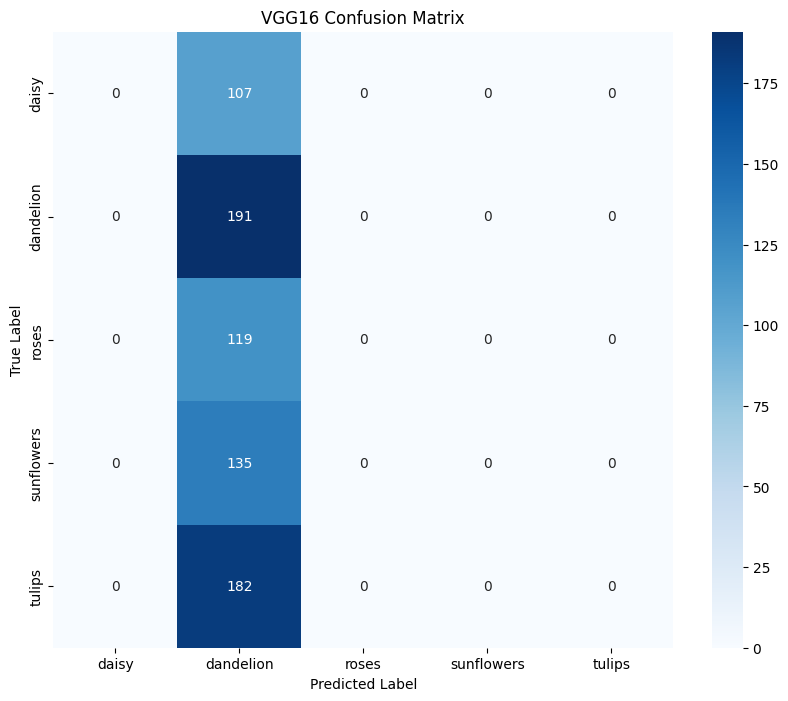

In [69]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("VGG16 Confusion Matrix")
plt.show()

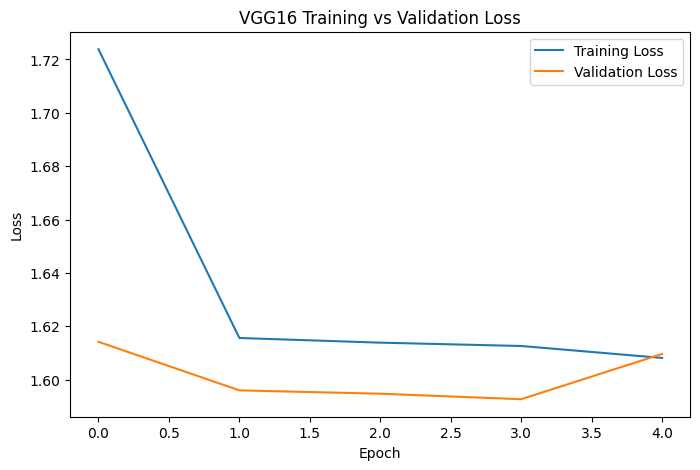

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(histor.history["loss"], label="Training Loss")
plt.plot(histor.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 Training vs Validation Loss")

plt.legend()
plt.show()

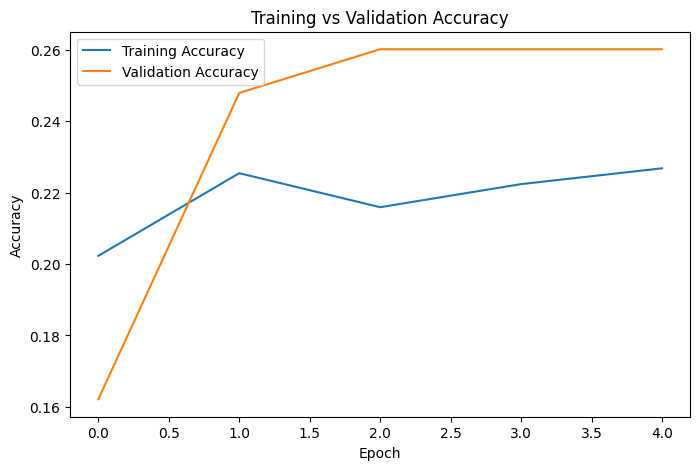

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(histor.history["accuracy"], label="Training Accuracy")
plt.plot(histor.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

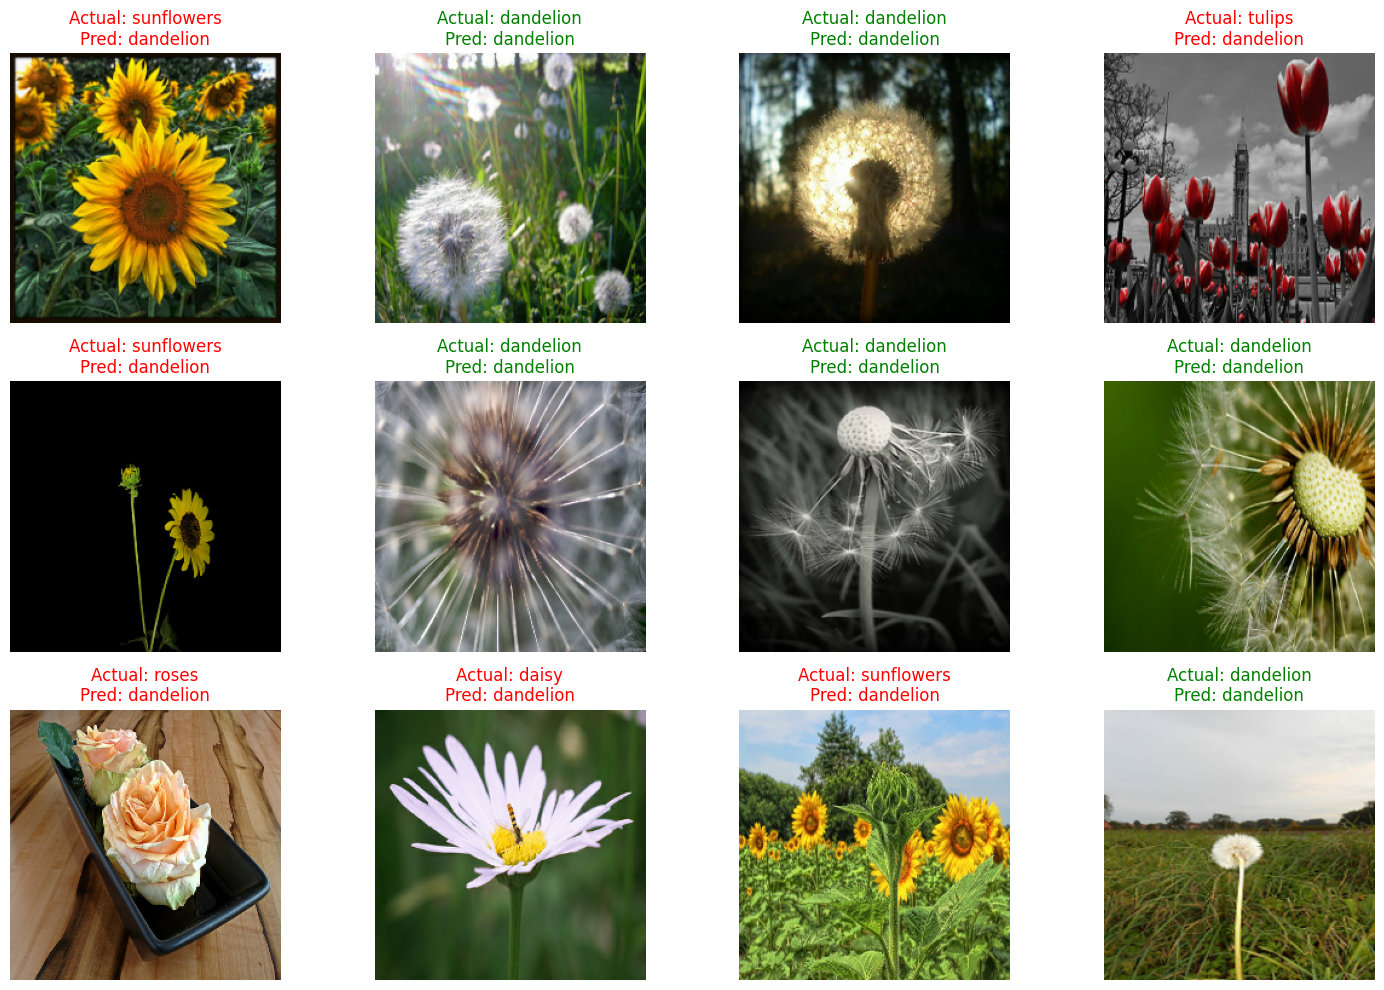

In [76]:
plt.figure(figsize=(15, 10))

for images, labels in test_dataset.take(1):
    predictions = model.predict(images, verbose=0)
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        actual_label = class_names[labels[i]]
        predicted_label = class_names[np.argmax(predictions[i])]
        color = "green" if actual_label == predicted_label else "red"

        plt.title(f"Actual: {actual_label}\nPred: {predicted_label}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()